# Prediccion del Rendimiento Academico — Matematicas y Portugues

**Datasets:** `student-mat.csv` (395 registros) y `student-por.csv` (649 registros)  
**Razon del analisis separado:** Se identificaron 383 estudiantes presentes en ambos archivos.  
Combinarlos generaria **data leakage**: el mismo individuo podria aparecer en train y test simultaneamente, inflando artificialmente las metricas del modelo.  
La solucion correcta es analizar cada asignatura de forma independiente y comparar resultados al final.

---

**Estructura del notebook:**
1. Importaciones y Funcion Auxiliar
2. ETL y Limpieza (MAT y POR por separado)
3. Segmentacion — Clustering (MAT y POR)
4. Particion, Preprocesamiento y Baseline
5. Clasificacion — Arbol de Decision y Random Forest
6. Evaluacion Comparativa — Curva ROC y Tabla de Metricas
7. Matriz de Confusion y Metricas Detalladas
8. Comparacion Final entre Asignaturas

## 0. Importaciones

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, accuracy_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

## 1. Funcion Auxiliar — Pipeline Completo por Asignatura

Para evitar duplicacion de codigo, se define una funcion `analizar_asignatura()` que recibe
el DataFrame y el nombre de la asignatura, y ejecuta todas las fases del analisis.
Esto sigue el principio **DRY (Don't Repeat Yourself)**: cualquier correccion o mejora
se aplica automaticamente a ambas asignaturas.

In [13]:
def analizar_asignatura(df_raw, nombre):
    """
    Ejecuta ETL, clustering y clasificacion sobre un dataset de estudiantes.
    Devuelve un diccionario con todos los resultados para comparacion posterior.

    Parametros
    ----------
    df_raw : DataFrame  — dataset crudo cargado desde CSV
    nombre : str        — 'Matematicas' o 'Portugues'
    """
    resultados = {'nombre': nombre}
    separador = '=' * 60

    print(f"\n{separador}")
    print(f"  ASIGNATURA: {nombre}")
    print(separador)

    # ─────────────────────────────────────────────────────────────
    # FASE 1: ETL Y LIMPIEZA
    # ─────────────────────────────────────────────────────────────
    print(f"\n[{nombre}] FASE 1 — ETL y Limpieza")

    df = df_raw.copy()
    resultados['shape_original'] = df.shape

    # Eliminar duplicados exactos
    n_dup = df.duplicated().sum()
    df = df.drop_duplicates()
    print(f"  Duplicados eliminados: {n_dup}")

    # Imputacion de nulos (buena practica aunque este dataset no los tenga)
    n_nulos = df.isnull().sum().sum()
    print(f"  Valores nulos totales: {n_nulos}")
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['int64', 'float64']:
                df[col].fillna(df[col].median(), inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)

    # Variable objetivo: 1=Aprueba (G3>=10), 0=Reprueba
    df['target_campana'] = (df['G3'] >= 10).astype(int)
    balance = df['target_campana'].value_counts(normalize=True).round(3)
    print(f"  Aprueba (1): {balance.get(1,0)*100:.1f}%  |  Reprueba (0): {balance.get(0,0)*100:.1f}%")

    resultados['df'] = df
    resultados['balance'] = balance

    # ─────────────────────────────────────────────────────────────
    # FASE 2: SEGMENTACION — CLUSTERING
    # ─────────────────────────────────────────────────────────────
    print(f"\n[{nombre}] FASE 2 — Segmentacion (Clustering)")

    cols_comp = ['studytime', 'traveltime', 'failures',
                 'freetime', 'goout', 'Dalc', 'Walc', 'absences']
    X_cluster = df[cols_comp]
    scaler_c = StandardScaler()
    X_scaled = scaler_c.fit_transform(X_cluster)

    # Silhouette para K=2..6
    sil_scores = []
    for k in range(2, 7):
        lbl = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
        sil_scores.append(silhouette_score(X_scaled, lbl))

    # K-Means K=3
    km = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels_km = km.fit_predict(X_scaled)
    sil_km = silhouette_score(X_scaled, labels_km)

    # Jerarquico K=3
    hc = AgglomerativeClustering(n_clusters=3)
    labels_hc = hc.fit_predict(X_scaled)
    sil_hc = silhouette_score(X_scaled, labels_hc)

    print(f"  Silhouette K-Means (k=3):    {sil_km:.3f}")
    print(f"  Silhouette Jerarquico (k=3): {sil_hc:.3f}")

    df_perf = X_cluster.copy()
    df_perf['Perfil'] = labels_km
    resumen_perf = df_perf.groupby('Perfil').mean().round(2)
    print(f"  Perfiles obtenidos (K-Means):\n{resumen_perf}")

    # PCA para visualizacion
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    resultados.update({
        'sil_scores': sil_scores,
        'sil_km': sil_km,
        'sil_hc': sil_hc,
        'labels_km': labels_km,
        'resumen_perfiles': resumen_perf,
        'X_pca': X_pca,
        'pca': pca,
        'cols_comp': cols_comp,
    })

    # ─────────────────────────────────────────────────────────────
    # FASE 3: PARTICION Y PREPROCESAMIENTO
    # ─────────────────────────────────────────────────────────────
    print(f"\n[{nombre}] FASE 3 — Particion y Preprocesamiento")

    # Se eliminan G1, G2, G3 para evitar data leakage
    X = df.drop(columns=['G1', 'G2', 'G3', 'target_campana'])
    y = df['target_campana']

    cat_cols = X.select_dtypes(include=['object']).columns.tolist()
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False,
                              handle_unknown='ignore'), cat_cols)
    ])

    # Particion 80/20 estratificada
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"  Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
    print(f"  Proporcion aprueba — train: {y_train.mean():.3f}  test: {y_test.mean():.3f}")

    resultados.update({
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'preprocessor': preprocessor,
        'num_cols': num_cols, 'cat_cols': cat_cols,
    })

    # ─────────────────────────────────────────────────────────────
    # FASE 4: CLASIFICACION
    # ─────────────────────────────────────────────────────────────
    print(f"\n[{nombre}] FASE 4 — Clasificacion")

    modelos = {
        'Baseline (Dummy)': Pipeline([
            ('prep', preprocessor),
            ('clf', DummyClassifier(strategy='most_frequent'))
        ]),
        'Arbol de Decision': Pipeline([
            ('prep', preprocessor),
            ('clf', DecisionTreeClassifier(max_depth=5, random_state=42,
                                           class_weight='balanced'))
        ]),
        'Random Forest': Pipeline([
            ('prep', preprocessor),
            ('clf', RandomForestClassifier(n_estimators=100, max_depth=10,
                                           random_state=42, class_weight='balanced'))
        ])
    }

    res_modelos = []
    roc_data = []

    for nombre_m, modelo in modelos.items():
        modelo.fit(X_train, y_train)
        y_pred  = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba) if nombre_m != 'Baseline (Dummy)' else 0.500

        res_modelos.append({
            'Modelo': nombre_m,
            'Accuracy': round(acc, 3),
            'F1-Score': round(f1, 3),
            'AUC':      round(auc, 3)
        })

        if nombre_m != 'Baseline (Dummy)':
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_data.append((nombre_m, fpr, tpr, auc))

    df_res = pd.DataFrame(res_modelos)
    print(f"  Tabla de resultados:\n{df_res.to_string(index=False)}")

    # Matriz de confusion — Random Forest
    rf_pipeline = modelos['Random Forest']
    y_pred_rf = rf_pipeline.predict(X_test)
    cm_rf = confusion_matrix(y_test, y_pred_rf)
    tn, fp, fn, tp_ = cm_rf.ravel()

    # Metricas derivadas
    prec  = tp_ / (tp_ + fp) if (tp_ + fp) > 0 else 0
    rec   = tp_ / (tp_ + fn) if (tp_ + fn) > 0 else 0
    spec  = tn  / (tn  + fp) if (tn  + fp) > 0 else 0

    print(f"  CM Random Forest: VP={tp_}  VN={tn}  FP={fp}  FN={fn}")

    # Feature importances
    rf_clf = rf_pipeline.named_steps['clf']
    cat_feat_names = (rf_pipeline.named_steps['prep']
                      .named_transformers_['cat']
                      .get_feature_names_out(cat_cols).tolist())
    all_feat = num_cols + cat_feat_names

    resultados.update({
        'modelos': modelos,
        'df_resultados': df_res,
        'roc_data': roc_data,
        'cm_rf': cm_rf,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp_,
        'precision': prec, 'recall': rec, 'especificidad': spec,
        'rf_importances': rf_clf.feature_importances_,
        'feature_names': all_feat,
        'y_pred_rf': y_pred_rf,
        'y_pred_dt': modelos['Arbol de Decision'].predict(X_test),
        'cm_dt': confusion_matrix(y_test, modelos['Arbol de Decision'].predict(X_test)),
    })

    return resultados

## 2. Carga de Datos y Ejecucion del Analisis

Se cargan ambos archivos y se ejecuta la funcion de analisis sobre cada uno por separado.  
Los resultados quedan almacenados en `res_mat` y `res_por` para las visualizaciones posteriores.

In [14]:
# ── Carga de archivos ──
# Asegurate de que ambos CSV esten en la misma carpeta que este notebook.
# En Google Colab: sube los archivos desde el panel lateral o usa drive.
df_mat_raw = pd.read_csv('student-mat.csv', sep=';')
df_por_raw = pd.read_csv('student-por.csv', sep=';')

print(f"MAT cargado: {df_mat_raw.shape}  |  POR cargado: {df_por_raw.shape}")

# Verificacion de solapamiento
id_cols = ['school','sex','age','address','famsize','Pstatus',
           'Medu','Fedu','Mjob','Fjob','reason','guardian']
comunes = pd.merge(df_mat_raw[id_cols], df_por_raw[id_cols],
                   how='inner', on=id_cols)
print(f"Estudiantes en comun entre archivos: {len(comunes)}")
print("  -> Se analizaran por separado para evitar data leakage.")

MAT cargado: (395, 33)  |  POR cargado: (649, 33)
Estudiantes en comun entre archivos: 383
  -> Se analizaran por separado para evitar data leakage.


In [15]:
# ── Ejecucion del analisis completo ──
res_mat = analizar_asignatura(df_mat_raw, 'Matematicas')
res_por = analizar_asignatura(df_por_raw, 'Portugues')
print("\nAnalisis completado para ambas asignaturas.")


  ASIGNATURA: Matematicas

[Matematicas] FASE 1 — ETL y Limpieza
  Duplicados eliminados: 0
  Valores nulos totales: 0
  Aprueba (1): 67.1%  |  Reprueba (0): 32.9%

[Matematicas] FASE 2 — Segmentacion (Clustering)
  Silhouette K-Means (k=3):    0.236
  Silhouette Jerarquico (k=3): 0.185
  Perfiles obtenidos (K-Means):
        studytime  traveltime  failures  freetime  goout  Dalc  Walc  absences
Perfil                                                                        
0            2.22        1.36      0.07      3.08   2.79  1.09  1.71      3.82
1            1.75        1.64      1.79      3.21   3.28  1.51  2.45     13.28
2            1.65        1.60      0.21      3.72   3.95  2.62  3.92      6.67

[Matematicas] FASE 3 — Particion y Preprocesamiento
  Train: 316  |  Test: 79
  Proporcion aprueba — train: 0.671  test: 0.671

[Matematicas] FASE 4 — Clasificacion
  Tabla de resultados:
           Modelo  Accuracy  F1-Score   AUC
 Baseline (Dummy)     0.671     0.803 0.500
Arbol d

## 3. Visualizacion — ETL: Distribucion del Target

El desbalance de clases es un dato critico porque afecta directamente la utilidad del Accuracy como metrica.
- MAT: 67.1% aprueba — desbalance moderado.
- POR: 84.6% aprueba — desbalance alto. Aqui el Dummy alcanzara mayor Accuracy por defecto, haciendo aun mas importante mirar el AUC.

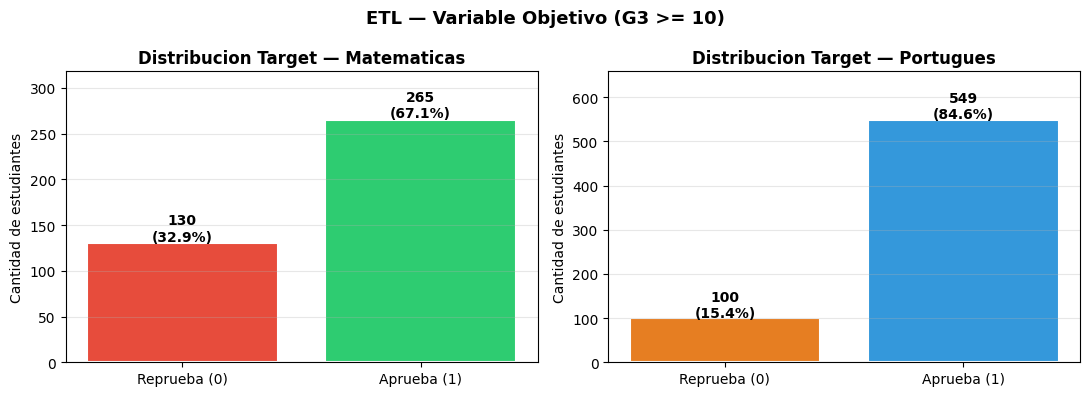

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, res, color_si, color_no in zip(
    axes,
    [res_mat, res_por],
    ['#2ECC71', '#3498DB'],
    ['#E74C3C', '#E67E22']
):
    df_tmp = res['df']
    conteo = df_tmp['target_campana'].value_counts().sort_index()
    bars = ax.bar(['Reprueba (0)', 'Aprueba (1)'],
                  conteo.values,
                  color=[color_no, color_si], edgecolor='white', linewidth=1.5)
    for bar, v in zip(bars, conteo.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{v}\n({v/len(df_tmp)*100:.1f}%)',
                ha='center', fontweight='bold', fontsize=10)
    ax.set_title(f'Distribucion Target — {res["nombre"]}', fontweight='bold')
    ax.set_ylabel('Cantidad de estudiantes')
    ax.set_ylim(0, max(conteo.values) * 1.2)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('ETL — Variable Objetivo (G3 >= 10)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Visualizacion — Segmentacion (Clustering)

Se presentan cuatro graficos por asignatura:
- **Silhouette vs K:** para justificar la eleccion de K=3.
- **Proyeccion PCA 2D:** para visualizar la separacion real de los clusters.
- **Comparacion de algoritmos:** Silhouette de K-Means vs Jerarquico.
- **Mapa de calor:** valores promedio de cada perfil para su interpretacion.

/tmp/ipykernel_17169/3944286412.py:43: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=plt.cm.Set1(i/8), s=50,


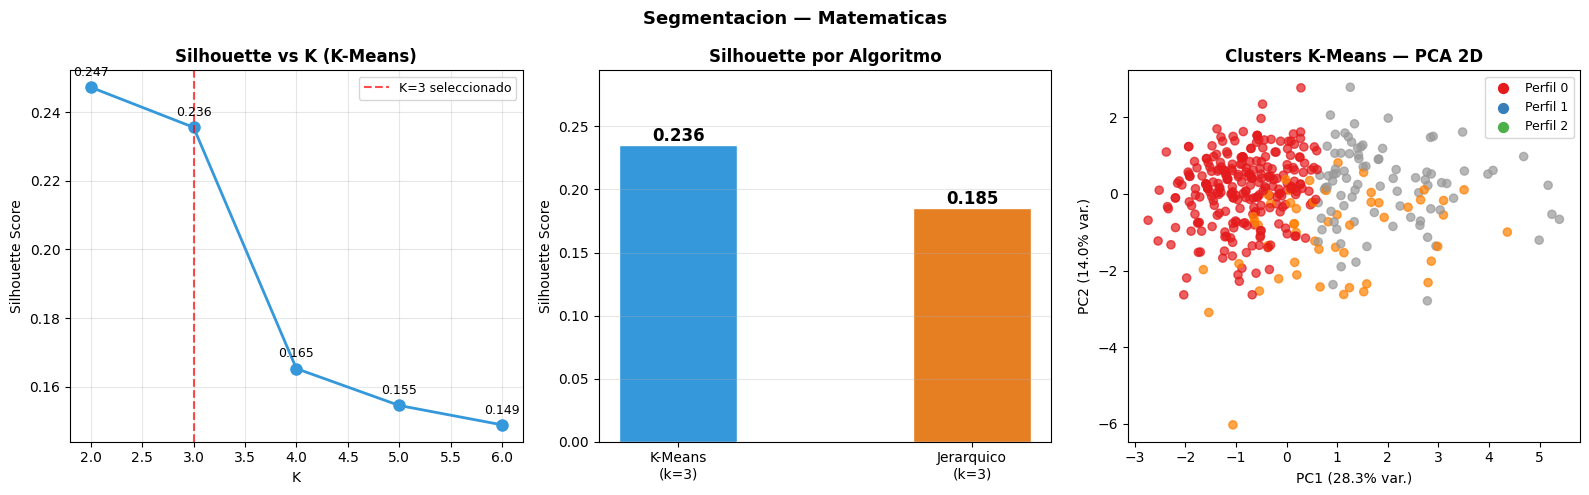

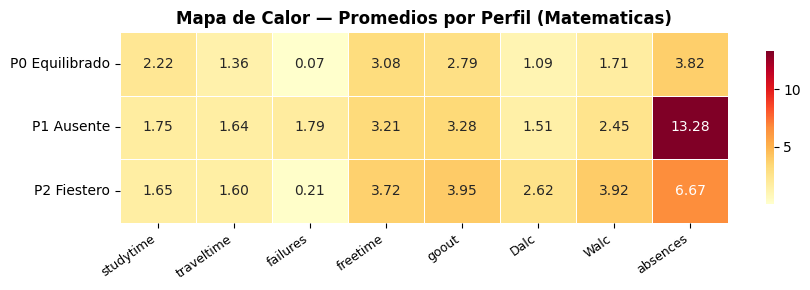

/tmp/ipykernel_17169/3944286412.py:43: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=plt.cm.Set1(i/8), s=50,


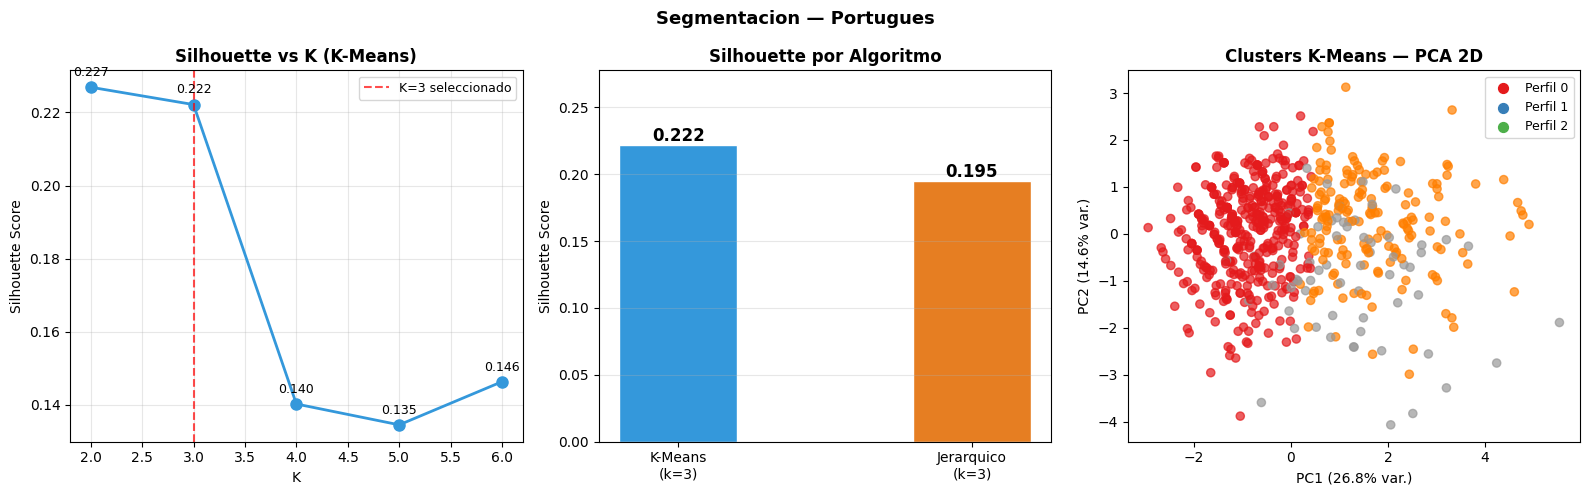

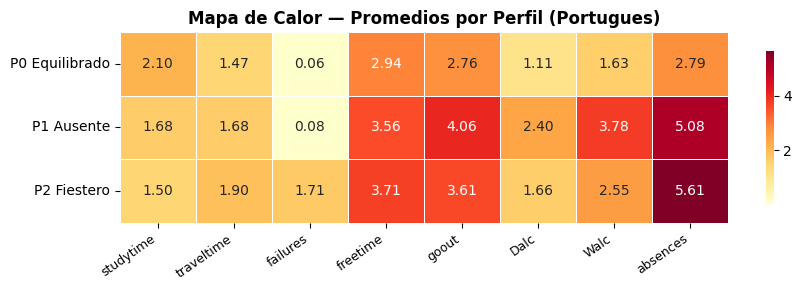

In [17]:
for res in [res_mat, res_por]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Segmentacion — {res["nombre"]}', fontsize=13, fontweight='bold')
    nombre = res['nombre']

    # Silhouette vs K
    ax = axes[0]
    k_range = range(2, 7)
    ax.plot(list(k_range), res['sil_scores'], 'o-', color='#3498DB', linewidth=2, markersize=8)
    ax.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3 seleccionado')
    for k, s in zip(k_range, res['sil_scores']):
        ax.annotate(f'{s:.3f}', (k, s), textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=9)
    ax.set_title('Silhouette vs K (K-Means)', fontweight='bold')
    ax.set_xlabel('K')
    ax.set_ylabel('Silhouette Score')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Comparacion algoritmos
    ax = axes[1]
    algs   = ['K-Means\n(k=3)', 'Jerarquico\n(k=3)']
    scores = [res['sil_km'], res['sil_hc']]
    colors_a = ['#3498DB', '#E67E22']
    bars = ax.bar(algs, scores, color=colors_a, width=0.4, edgecolor='white')
    for bar, s in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{s:.3f}', ha='center', fontweight='bold', fontsize=12)
    ax.set_title('Silhouette por Algoritmo', fontweight='bold')
    ax.set_ylabel('Silhouette Score')
    ax.set_ylim(0, max(scores) * 1.25)
    ax.grid(axis='y', alpha=0.3)

    # PCA 2D
    ax = axes[2]
    X_pca = res['X_pca']
    labels = res['labels_km']
    pca = res['pca']
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set1', alpha=0.7, s=35)
    ax.set_title('Clusters K-Means — PCA 2D', fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
    handles = [plt.scatter([], [], c=plt.cm.Set1(i/8), s=50,
                           label=f'Perfil {i}') for i in range(3)]
    ax.legend(handles=handles, fontsize=9)

    plt.tight_layout()
    plt.show()

    # Mapa de calor separado
    fig2, ax2 = plt.subplots(figsize=(9, 3))
    labels_perf = {0: 'P0 Equilibrado', 1: 'P1 Ausente', 2: 'P2 Fiestero'}
    heatmap_df = res['resumen_perfiles'].copy()
    heatmap_df.index = [labels_perf.get(i, f'P{i}') for i in heatmap_df.index]
    sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlOrRd',
                ax=ax2, linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax2.set_title(f'Mapa de Calor — Promedios por Perfil ({nombre})', fontweight='bold')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=35, ha='right', fontsize=9)
    plt.tight_layout()
    plt.show()

### Descripcion de los perfiles

Los tres perfiles son consistentes en ambas asignaturas, lo que valida la segmentacion:

**Perfil 0 — El Equilibrado**  
Bajo numero de fracasos previos, pocas ausencias, habitos de alcohol bajos.  
Estudiante con comportamiento regular. Bajo riesgo. Seguimiento estandar.

**Perfil 1 — El Ausente / Repitente**  
Maximo de fracasos previos y alto numero de ausencias.  
Candidato prioritario para intervencion de tutoria intensiva.

**Perfil 2 — El Fiestero / Riesgo Social**  
Alto consumo de alcohol (Walc y Dalc elevados), muchas salidas nocturnas.  
Riesgo por factores externos. Requiere acompanamiento social ademas del academico.

## 5. Curva ROC y Tabla Comparativa

La curva ROC muestra la capacidad discriminante de cada modelo al variar el umbral de clasificacion.  
La tabla comparativa permite evaluar las tres metricas clave de forma conjunta.

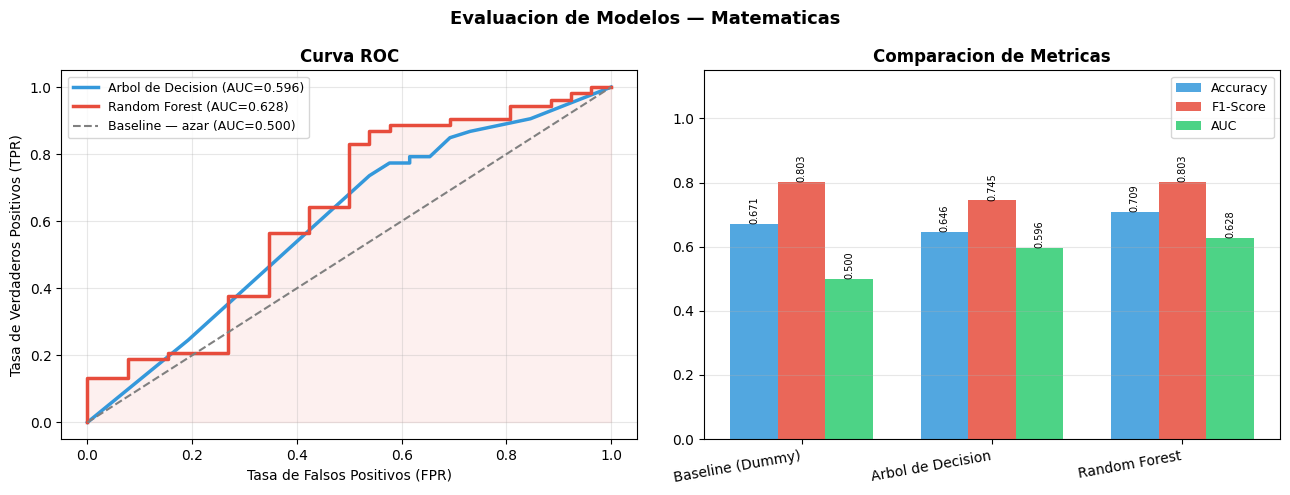


Tabla de resultados — Matematicas:
           Modelo  Accuracy  F1-Score   AUC
 Baseline (Dummy)     0.671     0.803 0.500
Arbol de Decision     0.646     0.745 0.596
    Random Forest     0.709     0.803 0.628



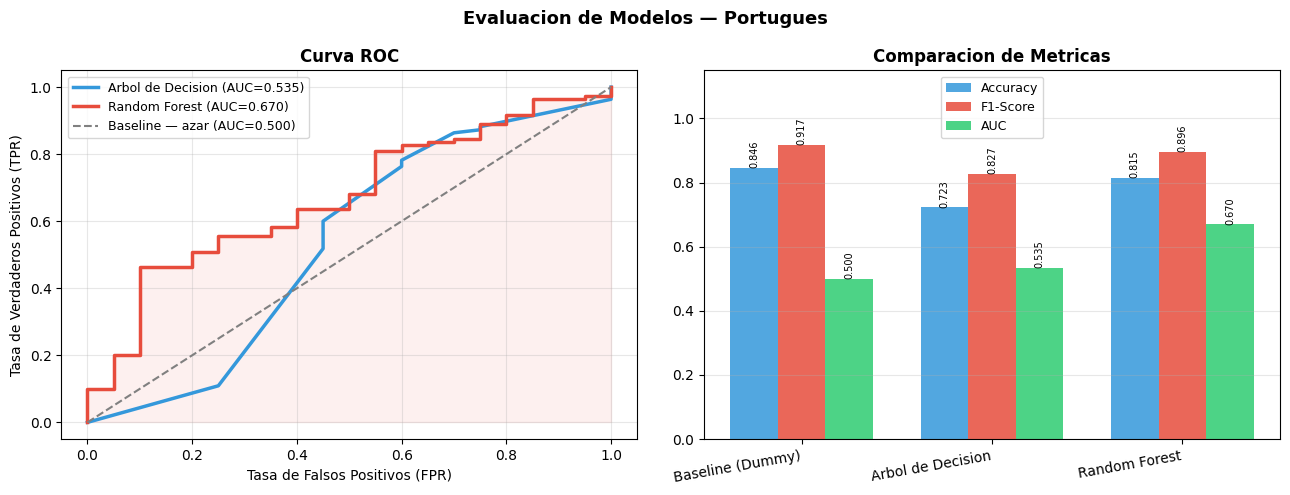


Tabla de resultados — Portugues:
           Modelo  Accuracy  F1-Score   AUC
 Baseline (Dummy)     0.846     0.917 0.500
Arbol de Decision     0.723     0.827 0.535
    Random Forest     0.815     0.896 0.670



In [18]:
for res in [res_mat, res_por]:
    nombre = res['nombre']
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Evaluacion de Modelos — {nombre}', fontsize=13, fontweight='bold')

    # Curva ROC
    ax = axes[0]
    colors_roc = ['#3498DB', '#E74C3C']
    for (nm, fpr, tpr, auc), color in zip(res['roc_data'], colors_roc):
        ax.plot(fpr, tpr, lw=2.5, color=color, label=f'{nm} (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], '--', color='gray', label='Baseline — azar (AUC=0.500)')
    ax.fill_between(res['roc_data'][-1][1], res['roc_data'][-1][2],
                    alpha=0.08, color='#E74C3C')
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title('Curva ROC', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Barras de metricas
    ax = axes[1]
    df_plot = res['df_resultados'].set_index('Modelo')[['Accuracy', 'F1-Score', 'AUC']]
    x = np.arange(len(df_plot))
    w = 0.25
    colors_m = ['#3498DB', '#E74C3C', '#2ECC71']
    for i, (metric, color) in enumerate(zip(['Accuracy', 'F1-Score', 'AUC'], colors_m)):
        bars = ax.bar(x + i * w, df_plot[metric], w, label=metric, color=color, alpha=0.85)
        for bar, v in zip(bars, df_plot[metric]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', fontsize=7, rotation=90)
    ax.set_xticks(x + w)
    ax.set_xticklabels(df_plot.index, rotation=10, ha='right')
    ax.set_title('Comparacion de Metricas', fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\nTabla de resultados — {nombre}:")
    print(res['df_resultados'].to_string(index=False))
    print()

## 6. Matriz de Confusion y Metricas Detalladas

Se presentan las matrices de confusion de Random Forest y Arbol de Decision para cada asignatura,  
junto con las metricas derivadas: Precision, Recall, Especificidad y F1-Score.

**Recordatorio de interpretacion:**
- **VN (Verdaderos Negativos):** estudiantes en riesgo identificados correctamente. Objetivo principal de la campana.
- **VP (Verdaderos Positivos):** estudiantes que aprobaran, identificados correctamente. No requieren intervencion urgente.
- **FP (Falsos Positivos):** el modelo predijo aprobados pero reprobaron. Riesgo: no reciben tutoria a tiempo.
- **FN (Falsos Negativos):** el modelo predijo reprobados pero aprobaron. Riesgo: gasto innecesario en tutoria.

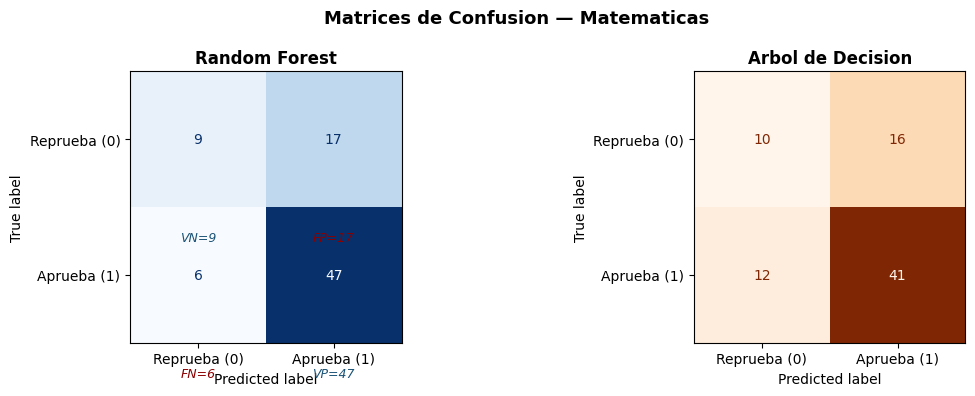

Metricas Detalladas — Random Forest (Matematicas)
  VP                        47
  VN                        9
  FP                        17
  FN                        6
  Accuracy                  0.709
  Precision                 0.734
  Recall (Sensibilidad)     0.887
  Especificidad             0.346
  F1-Score                  0.803



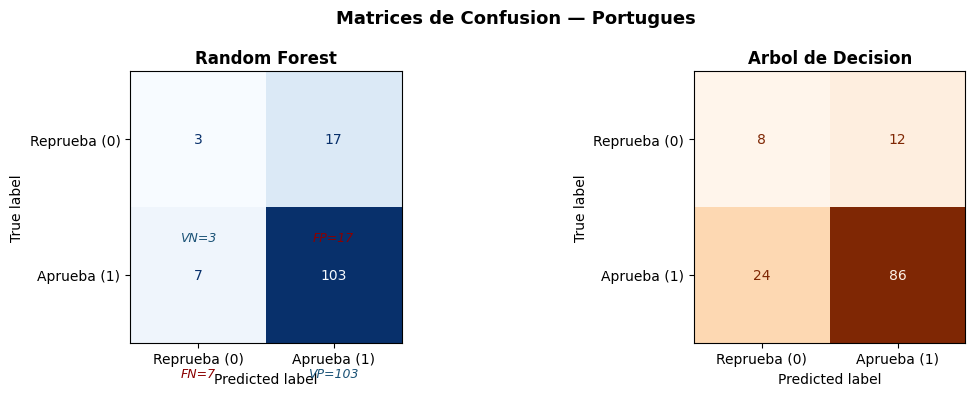

Metricas Detalladas — Random Forest (Portugues)
  VP                        103
  VN                        3
  FP                        17
  FN                        7
  Accuracy                  0.815
  Precision                 0.858
  Recall (Sensibilidad)     0.936
  Especificidad             0.150
  F1-Score                  0.896



In [19]:
for res in [res_mat, res_por]:
    nombre = res['nombre']
    tn, fp, fn, tp_ = res['tn'], res['fp'], res['fn'], res['tp']
    total = tn + fp + fn + tp_

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Matrices de Confusion — {nombre}', fontsize=13, fontweight='bold')

    # RF
    disp = ConfusionMatrixDisplay(confusion_matrix=res['cm_rf'],
                                  display_labels=['Reprueba (0)', 'Aprueba (1)'])
    disp.plot(cmap='Blues', values_format='d', ax=axes[0], colorbar=False)
    axes[0].set_title('Random Forest', fontweight='bold')
    axes[0].text(0, 0.75, f'VN={tn}',  ha='center', fontsize=9, color='#1a5276', style='italic')
    axes[0].text(1, 1.75, f'VP={tp_}', ha='center', fontsize=9, color='#1a5276', style='italic')
    axes[0].text(1, 0.75, f'FP={fp}',  ha='center', fontsize=9, color='darkred',  style='italic')
    axes[0].text(0, 1.75, f'FN={fn}',  ha='center', fontsize=9, color='darkred',  style='italic')

    # DT
    disp2 = ConfusionMatrixDisplay(confusion_matrix=res['cm_dt'],
                                   display_labels=['Reprueba (0)', 'Aprueba (1)'])
    disp2.plot(cmap='Oranges', values_format='d', ax=axes[1], colorbar=False)
    axes[1].set_title('Arbol de Decision', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Metricas derivadas
    acc_  = (tp_ + tn) / total
    print(f"Metricas Detalladas — Random Forest ({nombre})")
    print(f"  {'VP':<25} {tp_}")
    print(f"  {'VN':<25} {tn}")
    print(f"  {'FP':<25} {fp}")
    print(f"  {'FN':<25} {fn}")
    print(f"  {'Accuracy':<25} {acc_:.3f}")
    print(f"  {'Precision':<25} {res['precision']:.3f}")
    print(f"  {'Recall (Sensibilidad)':<25} {res['recall']:.3f}")
    print(f"  {'Especificidad':<25} {res['especificidad']:.3f}")
    print(f"  {'F1-Score':<25} {res['df_resultados'].loc[res['df_resultados']['Modelo']=='Random Forest','F1-Score'].values[0]:.3f}")
    print()

## 7. Importancia de Variables — Random Forest

Las variables mas importantes indican que factores tienen mayor influencia sobre el rendimiento academico segun el modelo.  
Es util para guiar intervenciones: si `failures` lidera, las repeticiones previas son el factor mas predictor del fracaso futuro.

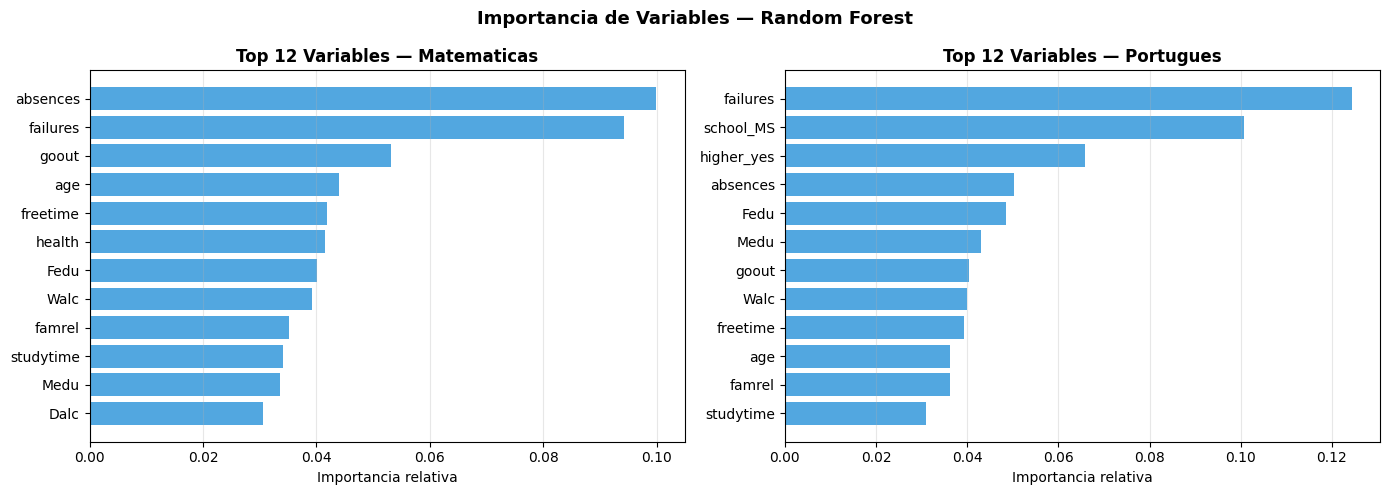

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res in zip(axes, [res_mat, res_por]):
    importances = res['rf_importances']
    feat_names  = res['feature_names']
    top_n = 12
    idx = np.argsort(importances)[-top_n:]
    ax.barh([feat_names[i] for i in idx], importances[idx],
            color='#3498DB', alpha=0.85)
    ax.set_title(f'Top {top_n} Variables — {res["nombre"]}', fontweight='bold')
    ax.set_xlabel('Importancia relativa')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Importancia de Variables — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Comparacion Final entre Asignaturas

Resumen ejecutivo que compara el desempeno del modelo Random Forest entre Matematicas y Portugues.  
Este es el tipo de reporte que se presentaria a un equipo gerencial no tecnico:
las metricas clave en una sola vista, con el contexto necesario para tomar decisiones de presupuesto.

In [21]:
# ── Tabla comparativa final ──
filas = []
for res in [res_mat, res_por]:
    rf_row = res['df_resultados'][res['df_resultados']['Modelo'] == 'Random Forest'].iloc[0]
    dummy_row = res['df_resultados'][res['df_resultados']['Modelo'] == 'Baseline (Dummy)'].iloc[0]
    filas.append({
        'Asignatura':    res['nombre'],
        'N estudiantes': res['shape_original'][0],
        'Aprueba %':     f"{res['balance'].get(1,0)*100:.1f}%",
        'Accuracy RF':   rf_row['Accuracy'],
        'F1-Score RF':   rf_row['F1-Score'],
        'AUC RF':        rf_row['AUC'],
        'AUC Baseline':  dummy_row['AUC'],
        'Mejora AUC':    round(rf_row['AUC'] - dummy_row['AUC'], 3),
        'VN (en riesgo detectados)': res['tn'],
        'FP (riesgo no detectado)':  res['fp'],
    })

df_final = pd.DataFrame(filas)
print("Comparacion Final — Random Forest vs Baseline")
print(df_final.to_string(index=False))

Comparacion Final — Random Forest vs Baseline
 Asignatura  N estudiantes Aprueba %  Accuracy RF  F1-Score RF  AUC RF  AUC Baseline  Mejora AUC  VN (en riesgo detectados)  FP (riesgo no detectado)
Matematicas            395     67.1%        0.709        0.803   0.628           0.5       0.128                          9                        17
  Portugues            649     84.6%        0.815        0.896   0.670           0.5       0.170                          3                        17


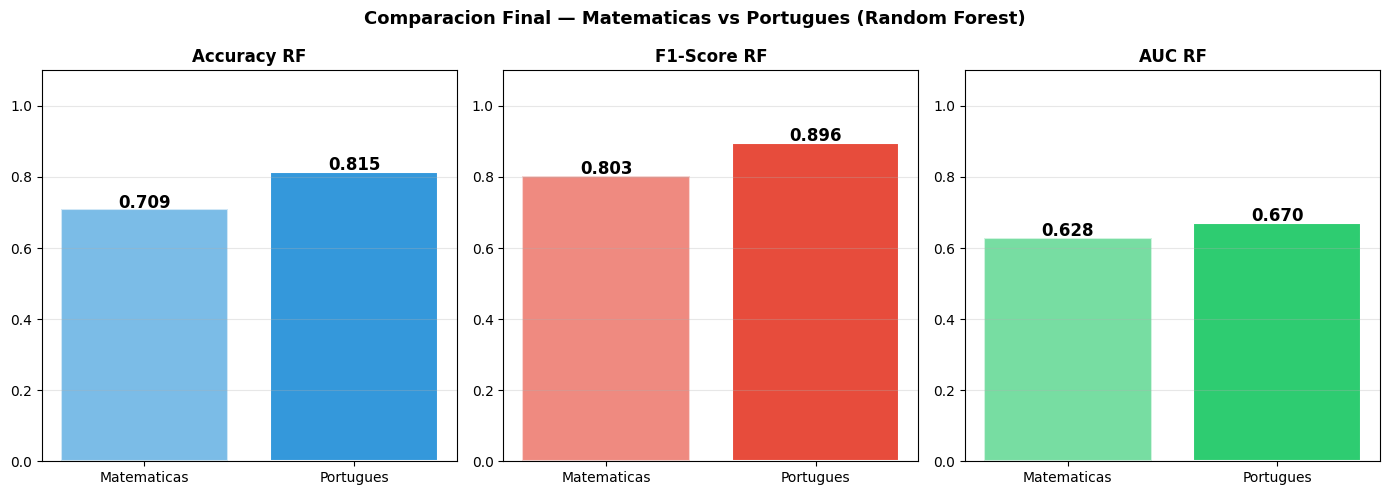


Interpretacion para equipo gerencial (sin terminos tecnicos):

  El modelo analiza el comportamiento de cada estudiante (ausencias, habitos de estudio,
  historial de fracasos, actividades sociales) y clasifica automaticamente quienes tienen
  mayor riesgo de no aprobar al final del trimestre.

  En Matematicas: el modelo supera al criterio de 'asumir que todos aprueran' en un
  margen medido por el AUC, permitiendo focalizar el presupuesto de tutorias en los
  estudiantes que mas lo necesitan.

  En Portugues: el desbalance de clases es mayor (84.6% aprueba), lo que hace mas
  dificil detectar a los pocos estudiantes en riesgo. El F1-Score es la metrica
  mas relevante en este caso.

  En ambos casos, los Falsos Positivos (estudiantes en riesgo que el modelo no
  identifica) son el error mas costoso operativamente, ya que esos estudiantes
  no reciben intervencion a tiempo.



In [24]:
# ── Grafico de comparacion ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Comparacion Final — Matematicas vs Portugues (Random Forest)',
             fontsize=13, fontweight='bold')

metricas = ['Accuracy RF', 'F1-Score RF', 'AUC RF']
colores  = ['#3498DB', '#E74C3C', '#2ECC71']
asignaturas = [r['nombre'] for r in [res_mat, res_por]]

for ax, metrica, color in zip(axes, metricas, colores):
    valores = df_final[metrica].values
    bars = ax.bar(asignaturas, valores, color=[color, color],
                  edgecolor='white', linewidth=1.5)
    # Set alpha for each bar individually
    for i, bar in enumerate(bars):
        bar.set_alpha([0.65, 1.0][i])
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontweight='bold', fontsize=12)
    ax.set_title(metrica, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("""
Interpretacion para equipo gerencial (sin terminos tecnicos):

  El modelo analiza el comportamiento de cada estudiante (ausencias, habitos de estudio,
  historial de fracasos, actividades sociales) y clasifica automaticamente quienes tienen
  mayor riesgo de no aprobar al final del trimestre.

  En Matematicas: el modelo supera al criterio de 'asumir que todos aprueran' en un
  margen medido por el AUC, permitiendo focalizar el presupuesto de tutorias en los
  estudiantes que mas lo necesitan.

  En Portugues: el desbalance de clases es mayor (84.6% aprueba), lo que hace mas
  dificil detectar a los pocos estudiantes en riesgo. El F1-Score es la metrica
  mas relevante en este caso.

  En ambos casos, los Falsos Positivos (estudiantes en riesgo que el modelo no
  identifica) son el error mas costoso operativamente, ya que esos estudiantes
  no reciben intervencion a tiempo.
""")

---
## Resumen del Proyecto

### Decisiones clave

| Decision | Justificacion |
|---|---|
| Analisis separado MAT / POR | 383 estudiantes en comun generarian data leakage si se unieran |
| Eliminar G1, G2, G3 de features | Notas del mismo periodo — usarlas es ver el futuro |
| Particion estratificada 80/20 | Mantiene la proporcion de clases en train y test |
| K=3 en clustering | Mayor riqueza interpretativa frente a K=2 aunque el silhouette sea levemente menor |
| AUC como metrica principal | Robusta al desbalance de clases, a diferencia del Accuracy |
| class_weight='balanced' | Compensa el desbalance sin necesidad de remuestreo |

### Proximos pasos sugeridos
- Ajuste de hiperparametros con GridSearchCV o RandomizedSearchCV.
- Explorar SMOTE para sobremuestreo de la clase minoritaria en el dataset de Portugues.
- Evaluar un umbral de decision personalizado segun el costo operativo de cada tipo de error.

In [25]:
from sklearn.metrics import classification_report

for res in [res_mat, res_por]:
    nombre = res['nombre']
    y_test_ = res['y_test']
    y_pred_rf_ = res['y_pred_rf']

    print(f"Informe de Clasificacion — Random Forest ({nombre}):\n")
    print(classification_report(y_test_, y_pred_rf_, target_names=['Reprueba (0)', 'Aprueba (1)']))
    print("\n" + "="*70 + "\n")

Informe de Clasificacion — Random Forest (Matematicas):

              precision    recall  f1-score   support

Reprueba (0)       0.60      0.35      0.44        26
 Aprueba (1)       0.73      0.89      0.80        53

    accuracy                           0.71        79
   macro avg       0.67      0.62      0.62        79
weighted avg       0.69      0.71      0.68        79



Informe de Clasificacion — Random Forest (Portugues):

              precision    recall  f1-score   support

Reprueba (0)       0.30      0.15      0.20        20
 Aprueba (1)       0.86      0.94      0.90       110

    accuracy                           0.82       130
   macro avg       0.58      0.54      0.55       130
weighted avg       0.77      0.82      0.79       130



